# **Hypothesis Tests**

## Project
**Using Machine Learning to Predict Complaint Resolution Outcomes in Retail Banking: Evidence from Open Consumer Financial Complaint Data**

## Purpose of this notebook
This notebook performs the first formal hypothesis tests for the capstone project. It uses the processed CFPB retail banking complaint dataset created in `01_data_extraction.ipynb` and explored in `02_exploratory_analysis.ipynb`.

The notebook focuses on four research questions:

### RQ1
**Does product type influence whether a company gives a timely response?**

- H0: Product type and timely response are independent.
- H1: Product type and timely response are significantly associated.

### RQ2
**Do complaint issue categories predict company response outcomes?**

- H0: Issue category and company response outcome are independent.
- H1: Issue category and company response outcome are significantly associated.

### RQ3
**Do complaint narratives improve prediction of timely response outcomes?**

- H0: Adding narrative-based features does not improve predictive performance.
- H1: Adding narrative-based features improves predictive performance.

### RQ4
**Are company-level and geographic differences significant after controlling for complaint characteristics?**

- H0: Company and geography are not significantly associated with timely response.
- H1: Company and geography are significantly associated with timely response.

## Important note
Because the dataset is large, some tests use the full dataset while model-based tests use a controlled sample. This keeps the notebook practical in Google Colab while still supporting the academic analysis.

## Statistical Methods Used

This notebook uses:

1. **Chi-square test of independence**  
   Used for categorical-variable association tests.

2. **Cramer's V**  
   Used as an effect-size measure for chi-square tests.

3. **Two-proportion z-test**  
   Used to compare two rates where applicable.

4. **Logistic regression model comparison**  
   Used as a practical test of whether narrative features improve prediction.

5. **Classification metrics**  
   ROC-AUC, F1-score, precision, recall, and accuracy are used to compare models.

Interpretation rule:

- A p-value below 0.05 suggests statistical significance.
- Statistical significance does not always mean practical importance.
- Effect size and business meaning should be interpreted together.

In [1]:
# -------------------------------------------------------------------
# Mount Google Drive
# -------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# -------------------------------------------------------------------
# Import libraries
# -------------------------------------------------------------------
from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# -------------------------------------------------------------------
# Project folders and file paths
# -------------------------------------------------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/retail-complaint-resolution-ml")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"

for folder in [DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_FIGURES]:
    folder.mkdir(parents=True, exist_ok=True)

PROCESSED_FILE = DATA_PROCESSED / "cfpb_retail_complaints_2017_2025.csv"

print("Project root:", PROJECT_ROOT)
print("Processed input file:", PROCESSED_FILE)
print("File exists:", PROCESSED_FILE.exists())

Project root: /content/drive/MyDrive/retail-complaint-resolution-ml
Processed input file: /content/drive/MyDrive/retail-complaint-resolution-ml/data/processed/cfpb_retail_complaints_2017_2025.csv
File exists: True


In [4]:
# -------------------------------------------------------------------
# Check processed dataset exists
# -------------------------------------------------------------------
if not PROCESSED_FILE.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Please run 01_data_extraction.ipynb first. "
        f"Expected file: {PROCESSED_FILE}"
    )

print("Processed dataset found.")
print(f"File size: {PROCESSED_FILE.stat().st_size / (1024**2):,.2f} MB")
print(f"Last modified: {datetime.fromtimestamp(PROCESSED_FILE.stat().st_mtime)}")

Processed dataset found.
File size: 1,241.13 MB
Last modified: 2026-07-15 21:18:36


## Step 1: Load Processed Dataset

The processed file is loaded from Google Drive. The notebook then confirms that the main target fields exist.

In [5]:
# -------------------------------------------------------------------
# Load processed dataset
# -------------------------------------------------------------------
df = pd.read_csv(PROCESSED_FILE, low_memory=False)

print("Dataset loaded.")
print("Rows:", f"{df.shape[0]:,}")
print("Columns:", f"{df.shape[1]:,}")

df.head()

Dataset loaded.
Rows: 1,289,027
Columns: 25


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id,date_received_raw,date_sent_to_company_raw,year_received,month_received,quarter_received,timely_response_binary,has_narrative,narrative_length,received_to_sent_lag_days
0,2025-07-05 08:45:32+00:00,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Changes in loan terms during the application p...,I signed an initial disclosure for a XXXX mort...,Company believes the complaint is the result o...,"Your Favorite Lenders, Inc",OH,441XX,NaN,Web,2026-05-05 13:43:00+00:00,Closed with explanation,Yes,21636268,2025-07-05T08:45:32.000Z,2026-05-05T13:43:00.000Z,2025,2025-07,2025Q3,1,1,516,304.0
1,2025-07-11 03:39:40+00:00,"Payday loan, title loan, personal loan, or adv...",Payday loan,Charged fees or interest you didn't expect,NaN,I am filing a complaint against Integra Credit...,NaN,"Deinde Online Services, LLC",FL,33068,NaN,Web,2026-04-21 17:42:21+00:00,Closed with explanation,Yes,21447929,2025-07-11T03:39:40.000Z,2026-04-21T17:42:21.000Z,2025,2025-07,2025Q3,1,1,998,284.0
2,2025-08-11 18:59:48+00:00,Mortgage,Conventional home mortgage,Struggling to pay mortgage,Trying to communicate with the company to fix ...,NaN,NaN,"Del Toro Loan Servicing, Inc",CA,94552,Older American,Phone,2025-08-15 06:00:26+00:00,Closed with explanation,No,15198684,2025-08-11T18:59:48.000Z,2025-08-15T06:00:26.000Z,2025,2025-08,2025Q3,0,0,0,3.0
3,2025-08-17 01:15:29+00:00,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,"Dear all, My name is XXXX XXXX, my address is ...",Company disputes the facts presented in the co...,"RESCO, INC.",HI,96815,NaN,Web,2026-05-04 13:13:09+00:00,Closed with explanation,Yes,21848458,2025-08-17T01:15:29.000Z,2026-05-04T13:13:09.000Z,2025,2025-08,2025Q3,1,1,1805,260.0
4,2025-09-25 15:49:13+00:00,Mortgage,VA mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,NaN,NaN,"Mortgage Express, Inc.",GA,30662,Servicemember,Web,2026-04-30 15:44:57+00:00,Closed with explanation,Yes,21669790,2025-09-25T15:49:13.000Z,2026-04-30T15:44:57.000Z,2025,2025-09,2025Q3,1,0,0,216.0


In [6]:
# -------------------------------------------------------------------
# Basic field preparation
# -------------------------------------------------------------------
# Convert dates if present
for col in ["date_received", "date_sent_to_company"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

# Create year if missing
if "year_received" not in df.columns and "date_received" in df.columns:
    df["year_received"] = df["date_received"].dt.year

# Create binary target if missing
if "timely_response_binary" not in df.columns:
    df["timely_response_binary"] = (
        df["timely_response"]
        .astype(str)
        .str.lower()
        .str.strip()
        .map({"yes": 1, "no": 0})
    )

# Create narrative features if missing
if "has_narrative" not in df.columns:
    df["has_narrative"] = df["consumer_complaint_narrative"].notna().astype(int)

if "narrative_length" not in df.columns:
    df["narrative_length"] = df["consumer_complaint_narrative"].fillna("").astype(str).str.len()

print("Preparation complete.")
print("Valid timely_response_binary records:", df["timely_response_binary"].notna().sum())

Preparation complete.
Valid timely_response_binary records: 1289027


## Step 2: Helper Functions

The following helper functions are used throughout the hypothesis testing notebook.

In [7]:
# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------
def save_table(table, filename):
    output_path = OUTPUT_TABLES / filename
    table.to_csv(output_path, index=False)
    print(f"Saved table: {output_path}")
    return output_path


def cramers_v_from_table(contingency_table):
    """Calculate Cramer's V effect size for a contingency table."""
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.values.sum()
    r, k = contingency_table.shape

    if n == 0 or min(r - 1, k - 1) == 0:
        return np.nan

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))


def run_chi_square_test(dataframe, row_var, col_var, filename_prefix):
    """Run chi-square test and save observed and expected tables."""
    test_df = dataframe[[row_var, col_var]].dropna().copy()

    observed = pd.crosstab(test_df[row_var], test_df[col_var])
    chi2, p_value, dof, expected = chi2_contingency(observed)

    effect_size = cramers_v_from_table(observed)

    summary = pd.DataFrame([{
        "row_variable": row_var,
        "column_variable": col_var,
        "n_records": int(observed.values.sum()),
        "chi_square": chi2,
        "degrees_of_freedom": dof,
        "p_value": p_value,
        "cramers_v": effect_size
    }])

    expected_df = pd.DataFrame(
        expected,
        index=observed.index,
        columns=observed.columns
    ).reset_index()

    observed_out = observed.reset_index()

    save_table(observed_out, f"{filename_prefix}_observed_counts.csv")
    save_table(expected_df, f"{filename_prefix}_expected_counts.csv")
    save_table(summary, f"{filename_prefix}_test_summary.csv")

    return summary, observed_out, expected_df


def interpret_p_value(p_value, alpha=0.05):
    if p_value < alpha:
        return "Reject H0: statistically significant association."
    return "Fail to reject H0: no statistically significant association."


def interpret_cramers_v(v):
    if pd.isna(v):
        return "Effect size unavailable."
    if v < 0.10:
        return "Very weak effect size."
    elif v < 0.30:
        return "Weak effect size."
    elif v < 0.50:
        return "Moderate effect size."
    else:
        return "Strong effect size."


def plot_metric_comparison(metric_table, title, filename):
    plot_df = metric_table.set_index("model")
    plt.figure(figsize=(10, 5))
    plot_df[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(kind="bar", figsize=(10, 5))
    plt.title(title)
    plt.ylabel("Score")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()

    output_path = OUTPUT_FIGURES / filename
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved figure:", output_path)
    return output_path


def evaluate_binary_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        roc_auc = np.nan

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc
    }

    return metrics, y_pred

## Step 3: Analysis Dataset

Rows with missing target values are removed. This creates the analysis-ready dataset used in the tests below.

In [8]:
# -------------------------------------------------------------------
# Build analysis dataset
# -------------------------------------------------------------------
analysis_df = df.dropna(subset=["timely_response_binary"]).copy()

print("Original rows:", f"{len(df):,}")
print("Rows with valid timely_response_binary:", f"{len(analysis_df):,}")

target_counts = analysis_df["timely_response_binary"].value_counts(dropna=False).reset_index()
target_counts.columns = ["timely_response_binary", "count"]
target_counts["percent"] = (target_counts["count"] / target_counts["count"].sum() * 100).round(2)

save_table(target_counts, "hypothesis_target_timely_response_binary_counts.csv")

target_counts

Original rows: 1,289,027
Rows with valid timely_response_binary: 1,289,027
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/hypothesis_target_timely_response_binary_counts.csv


,timely_response_binary,count,percent
0,1,1270902,98.59
1,0,18125,1.41


# RQ1: Product Type and Timely Response

## Research Question
Does product type influence whether a company gives a timely response?

## Hypotheses
- H0: Product type and timely response are independent.
- H1: Product type and timely response are significantly associated.

## Test Used
A chi-square test of independence is used because both variables are categorical.

In [9]:
# -------------------------------------------------------------------
# RQ1: Chi-square test for product type and timely response
# -------------------------------------------------------------------
rq1_summary, rq1_observed, rq1_expected = run_chi_square_test(
    analysis_df,
    row_var="product",
    col_var="timely_response",
    filename_prefix="rq1_product_timely_response"
)

rq1_summary["p_value_interpretation"] = rq1_summary["p_value"].apply(interpret_p_value)
rq1_summary["effect_size_interpretation"] = rq1_summary["cramers_v"].apply(interpret_cramers_v)

save_table(rq1_summary, "rq1_product_timely_response_final_summary.csv")

rq1_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_product_timely_response_observed_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_product_timely_response_expected_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_product_timely_response_test_summary.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_product_timely_response_final_summary.csv


,row_variable,column_variable,n_records,chi_square,degrees_of_freedom,p_value,cramers_v,p_value_interpretation,effect_size_interpretation
0,product,timely_response,1289027,11098.269857,13,0.0,0.092789,Reject H0: statistically significant association.,Very weak effect size.


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq1_timely_response_rate_by_product.csv


,product,total_records,timely_records,timely_rate,timely_rate_percent
13,Virtual currency,3,3,1.000000,100.00
3,Credit card,194996,194335,0.996610,99.66
1,Checking or savings account,333982,330627,0.989955,99.00
4,Credit card or prepaid card,206357,203925,0.988215,98.82
7,Mortgage,221283,218042,0.985354,98.54
5,"Money transfer, virtual currency, or money ser...",164638,162007,0.984019,98.40
12,Vehicle loan or lease,85430,83846,0.981459,98.15
10,"Payday loan, title loan, personal loan, or adv...",24745,23734,0.959143,95.91
9,"Payday loan, title loan, or personal loan",30622,29039,0.948305,94.83
11,Prepaid card,15540,14718,0.947104,94.71


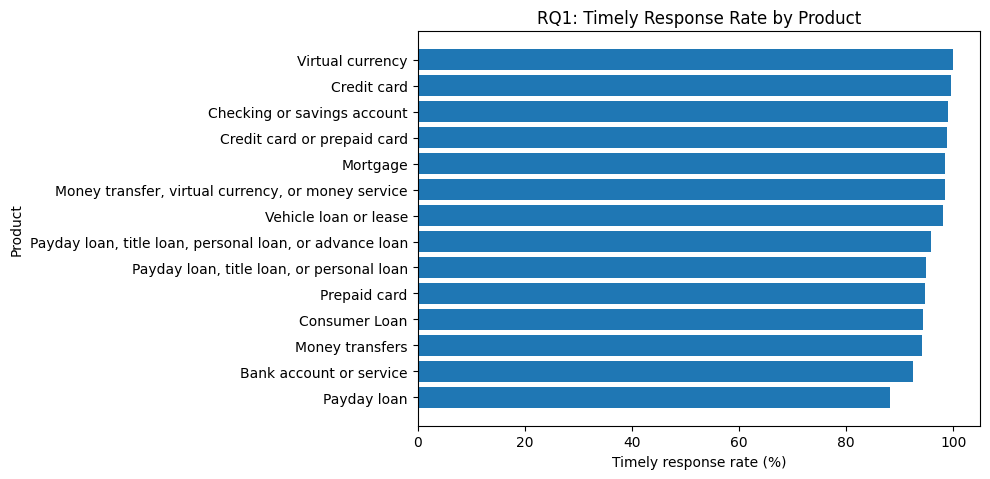

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/rq1_timely_response_rate_by_product.png


In [10]:
# -------------------------------------------------------------------
# RQ1: Timely response rate by product
# -------------------------------------------------------------------
rq1_rates = (
    analysis_df
    .groupby("product", dropna=False)
    .agg(
        total_records=("timely_response_binary", "size"),
        timely_records=("timely_response_binary", "sum"),
        timely_rate=("timely_response_binary", "mean")
    )
    .reset_index()
)

rq1_rates["timely_rate_percent"] = (rq1_rates["timely_rate"] * 100).round(2)
rq1_rates = rq1_rates.sort_values("timely_rate_percent", ascending=False)

save_table(rq1_rates, "rq1_timely_response_rate_by_product.csv")

display(rq1_rates)

plt.figure(figsize=(10, max(4, len(rq1_rates) * 0.35)))
plt.barh(rq1_rates.sort_values("timely_rate_percent")["product"].astype(str),
         rq1_rates.sort_values("timely_rate_percent")["timely_rate_percent"])
plt.title("RQ1: Timely Response Rate by Product")
plt.xlabel("Timely response rate (%)")
plt.ylabel("Product")
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "rq1_timely_response_rate_by_product.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

## RQ1 Preliminary Interpretation

Use the printed p-value and Cramer's V value above.

Suggested wording for the report:

> A chi-square test of independence was conducted to examine the association between product type and timely response. If the p-value is below 0.05, the null hypothesis is rejected, suggesting that timely response varies significantly by product type. However, Cramer's V should be used to assess whether the effect is practically meaningful.

# RQ2: Issue Category and Company Response Outcome

## Research Question
Do complaint issue categories predict company response outcomes?

## Hypotheses
- H0: Issue category and company response outcome are independent.
- H1: Issue category and company response outcome are significantly associated.

## Test Used
A chi-square test of independence is used. To keep the contingency table interpretable, the test uses the top issue categories and groups smaller categories into `Other`.

In [11]:
# -------------------------------------------------------------------
# RQ2: Prepare top issues for manageable hypothesis test
# -------------------------------------------------------------------
TOP_N_ISSUES = 25

rq2_df = analysis_df[["issue", "company_response_to_consumer"]].dropna().copy()

top_issues = rq2_df["issue"].value_counts().head(TOP_N_ISSUES).index
rq2_df["issue_grouped"] = np.where(rq2_df["issue"].isin(top_issues), rq2_df["issue"], "Other")

print("Rows used for RQ2:", f"{len(rq2_df):,}")
print("Top issue categories retained:", TOP_N_ISSUES)
print("Unique grouped issue values:", rq2_df["issue_grouped"].nunique())
print("Unique company response values:", rq2_df["company_response_to_consumer"].nunique())

Rows used for RQ2: 1,288,961
Top issue categories retained: 25
Unique grouped issue values: 26
Unique company response values: 6


In [12]:
# -------------------------------------------------------------------
# RQ2: Chi-square test for issue group and company response outcome
# -------------------------------------------------------------------
rq2_summary, rq2_observed, rq2_expected = run_chi_square_test(
    rq2_df,
    row_var="issue_grouped",
    col_var="company_response_to_consumer",
    filename_prefix="rq2_issue_company_response"
)

rq2_summary["p_value_interpretation"] = rq2_summary["p_value"].apply(interpret_p_value)
rq2_summary["effect_size_interpretation"] = rq2_summary["cramers_v"].apply(interpret_cramers_v)

save_table(rq2_summary, "rq2_issue_company_response_final_summary.csv")

rq2_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_observed_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_expected_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_test_summary.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_final_summary.csv


,row_variable,column_variable,n_records,chi_square,degrees_of_freedom,p_value,cramers_v,p_value_interpretation,effect_size_interpretation
0,issue_grouped,company_response_to_consumer,1288961,226378.933206,125,0.0,0.187419,Reject H0: statistically significant association.,Weak effect size.


In [13]:
# -------------------------------------------------------------------
# RQ2: Company response distribution by top issue
# -------------------------------------------------------------------
rq2_response_pct = pd.crosstab(
    rq2_df["issue_grouped"],
    rq2_df["company_response_to_consumer"],
    normalize="index"
).round(4) * 100

rq2_response_pct = rq2_response_pct.reset_index()

save_table(rq2_response_pct, "rq2_issue_company_response_percentage_table.csv")

rq2_response_pct

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq2_issue_company_response_percentage_table.csv


company_response_to_consumer,issue_grouped,Closed,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
0,"Advertising and marketing, including promotion...",0.00,70.69,15.83,13.41,0.01,0.06
1,Applying for a mortgage or refinancing an exis...,0.00,90.88,5.61,3.01,0.00,0.50
2,Charged fees or interest you didn't expect,0.00,89.19,6.39,2.92,0.00,1.49
3,Closing an account,0.00,80.21,12.13,7.62,0.00,0.04
4,Closing on a mortgage,0.00,89.64,6.48,3.24,0.02,0.62
5,Closing your account,0.00,80.15,8.10,11.69,0.00,0.06
6,Fees or interest,0.00,60.48,34.90,4.56,0.02,0.04
7,Fraud or scam,0.00,89.34,7.37,2.89,0.00,0.40
8,Getting a credit card,0.00,68.58,2.08,29.26,0.00,0.08
9,Incorrect information on your report,0.00,68.73,1.36,29.75,0.00,0.15


## RQ2 Preliminary Interpretation

Suggested wording for the report:

> A chi-square test of independence was conducted to examine whether issue category is associated with company response outcome. If the p-value is below 0.05, the result suggests that response outcomes differ across issue categories. Because the dataset is large, the effect size should be interpreted together with the p-value.

# RQ3: Narrative Features and Predictive Improvement

## Research Question
Do complaint narratives improve prediction of timely response outcomes?

## Hypotheses
- H0: Adding narrative-based features does not improve predictive performance.
- H1: Adding narrative-based features improves predictive performance.

## Test Approach
This notebook compares two logistic regression models:

1. **Structured-only model**
   - product
   - issue
   - submitted_via
   - state
   - year_received

2. **Structured + narrative model**
   - all structured features above
   - has_narrative
   - narrative_length

This is a preliminary hypothesis-style model comparison. Full machine learning development will continue in `04_model_training.ipynb`.

In [14]:
# -------------------------------------------------------------------
# RQ3: Create sample for model comparison
# -------------------------------------------------------------------
MODEL_SAMPLE_SIZE = 100_000
RANDOM_STATE = 42

model_df = analysis_df.copy()

# Keep only required fields
rq3_required_cols = [
    "timely_response_binary",
    "product",
    "issue",
    "submitted_via",
    "state",
    "year_received",
    "has_narrative",
    "narrative_length"
]

available_rq3_cols = [col for col in rq3_required_cols if col in model_df.columns]
model_df = model_df[available_rq3_cols].dropna(subset=["timely_response_binary"]).copy()

# Fill missing categorical values
for col in ["product", "issue", "submitted_via", "state", "year_received"]:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna("Unknown").astype(str)

# Fill missing numeric values
for col in ["has_narrative", "narrative_length"]:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce").fillna(0)

# Stratified sample to keep runtime reasonable
if len(model_df) > MODEL_SAMPLE_SIZE:
    model_df = (
        model_df
        .groupby("timely_response_binary", group_keys=False)
        .apply(lambda x: x.sample(
            n=max(1, int(MODEL_SAMPLE_SIZE * len(x) / len(analysis_df))),
            random_state=RANDOM_STATE
        ))
    )

# If the grouping-based sample is slightly off, cap it
if len(model_df) > MODEL_SAMPLE_SIZE:
    model_df = model_df.sample(n=MODEL_SAMPLE_SIZE, random_state=RANDOM_STATE)

print("Model comparison dataset shape:", model_df.shape)
display(model_df["timely_response_binary"].value_counts(normalize=True).reset_index())

Model comparison dataset shape: (99999, 8)


,timely_response_binary,proportion
0,1,0.98594
1,0,0.01406


In [15]:
# -------------------------------------------------------------------
# RQ3: Train-test split
# -------------------------------------------------------------------
y = model_df["timely_response_binary"].astype(int)

structured_features = ["product", "issue", "submitted_via", "state", "year_received"]
structured_features = [col for col in structured_features if col in model_df.columns]

narrative_features = ["has_narrative", "narrative_length"]
narrative_features = [col for col in narrative_features if col in model_df.columns]

X_structured = model_df[structured_features].copy()
X_with_narrative = model_df[structured_features + narrative_features].copy()

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_structured,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train_n, X_test_n, _, _ = train_test_split(
    X_with_narrative,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Structured features:", structured_features)
print("Narrative features:", narrative_features)
print("Training rows:", f"{len(X_train_s):,}")
print("Testing rows:", f"{len(X_test_s):,}")

Structured features: ['product', 'issue', 'submitted_via', 'state', 'year_received']
Narrative features: ['has_narrative', 'narrative_length']
Training rows: 69,999
Testing rows: 30,000


In [16]:
# -------------------------------------------------------------------
# RQ3: Structured-only logistic regression
# -------------------------------------------------------------------
categorical_structured = structured_features

structured_preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), categorical_structured)
    ],
    remainder="drop"
)

structured_model = Pipeline(steps=[
    ("preprocess", structured_preprocess),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced", solver="saga", n_jobs=-1))
])

structured_model.fit(X_train_s, y_train)

structured_metrics, structured_pred = evaluate_binary_model(
    structured_model,
    X_test_s,
    y_test,
    model_name="Structured only"
)

structured_metrics

{'model': 'Structured only',
 'accuracy': 0.5895333333333334,
 'precision': 0.9903988183161004,
 'recall': 0.5893907634052337,
 'f1': 0.7389995760915642,
 'roc_auc': np.float64(0.6411035373094964)}

In [17]:
# -------------------------------------------------------------------
# RQ3: Structured + narrative logistic regression
# -------------------------------------------------------------------
categorical_features = structured_features
numeric_features = narrative_features

with_narrative_preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

with_narrative_model = Pipeline(steps=[
    ("preprocess", with_narrative_preprocess),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced", solver="saga", n_jobs=-1))
])

with_narrative_model.fit(X_train_n, y_train)

with_narrative_metrics, with_narrative_pred = evaluate_binary_model(
    with_narrative_model,
    X_test_n,
    y_test,
    model_name="Structured + narrative"
)

with_narrative_metrics

{'model': 'Structured + narrative',
 'accuracy': 0.7055666666666667,
 'precision': 0.9916575816466796,
 'recall': 0.7073162485631213,
 'f1': 0.8256931425752343,
 'roc_auc': np.float64(0.6968304385320331)}

In [18]:
# -------------------------------------------------------------------
# RQ3: Model comparison table
# -------------------------------------------------------------------
rq3_model_comparison = pd.DataFrame([
    structured_metrics,
    with_narrative_metrics
])

for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    rq3_model_comparison[col] = rq3_model_comparison[col].round(4)

# Difference row
difference = {
    "model": "Difference: narrative minus structured",
    "accuracy": rq3_model_comparison.loc[1, "accuracy"] - rq3_model_comparison.loc[0, "accuracy"],
    "precision": rq3_model_comparison.loc[1, "precision"] - rq3_model_comparison.loc[0, "precision"],
    "recall": rq3_model_comparison.loc[1, "recall"] - rq3_model_comparison.loc[0, "recall"],
    "f1": rq3_model_comparison.loc[1, "f1"] - rq3_model_comparison.loc[0, "f1"],
    "roc_auc": rq3_model_comparison.loc[1, "roc_auc"] - rq3_model_comparison.loc[0, "roc_auc"],
}

rq3_model_comparison_final = pd.concat(
    [rq3_model_comparison, pd.DataFrame([difference])],
    ignore_index=True
)

for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    rq3_model_comparison_final[col] = rq3_model_comparison_final[col].round(4)

save_table(rq3_model_comparison_final, "rq3_model_comparison_structured_vs_narrative.csv")

rq3_model_comparison_final

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq3_model_comparison_structured_vs_narrative.csv


,model,accuracy,precision,recall,f1,roc_auc
0,Structured only,0.5895,0.9904,0.5894,0.7390,0.6411
1,Structured + narrative,0.7056,0.9917,0.7073,0.8257,0.6968
2,Difference: narrative minus structured,0.1161,0.0013,0.1179,0.0867,0.0557


<Figure size 1000x500 with 0 Axes>

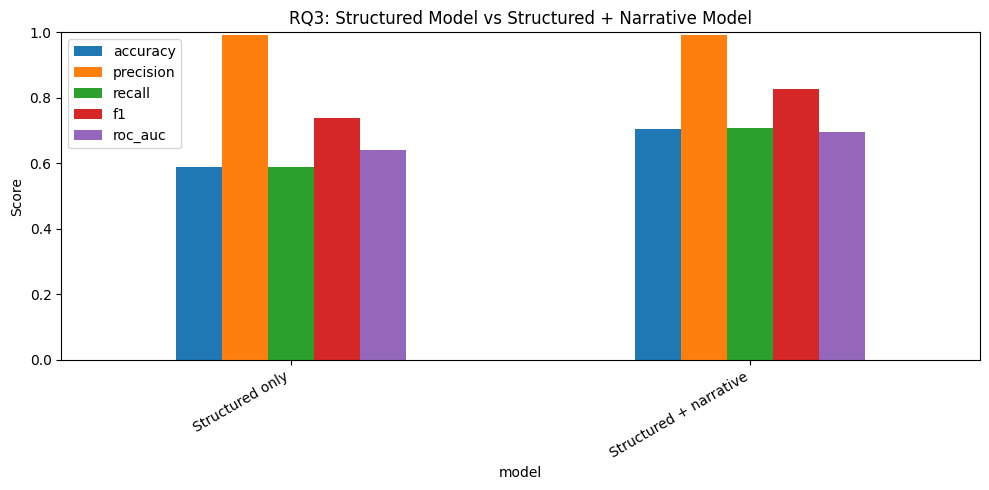

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/rq3_structured_vs_narrative_model_comparison.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/rq3_structured_vs_narrative_model_comparison.png')

In [19]:
# -------------------------------------------------------------------
# RQ3: Visual model comparison
# -------------------------------------------------------------------
plot_metric_comparison(
    rq3_model_comparison,
    title="RQ3: Structured Model vs Structured + Narrative Model",
    filename="rq3_structured_vs_narrative_model_comparison.png"
)

In [20]:
# -------------------------------------------------------------------
# RQ3: Confusion matrices
# -------------------------------------------------------------------
structured_cm = pd.DataFrame(
    confusion_matrix(y_test, structured_pred),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

with_narrative_cm = pd.DataFrame(
    confusion_matrix(y_test, with_narrative_pred),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

save_table(structured_cm.reset_index().rename(columns={"index": "actual"}), "rq3_structured_model_confusion_matrix.csv")
save_table(with_narrative_cm.reset_index().rename(columns={"index": "actual"}), "rq3_with_narrative_model_confusion_matrix.csv")

print("Structured-only confusion matrix")
display(structured_cm)

print("Structured + narrative confusion matrix")
display(with_narrative_cm)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq3_structured_model_confusion_matrix.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq3_with_narrative_model_confusion_matrix.csv
Structured-only confusion matrix


,Predicted 0,Predicted 1
Actual 0,253,169
Actual 1,12145,17433


Structured + narrative confusion matrix


,Predicted 0,Predicted 1
Actual 0,246,176
Actual 1,8657,20921


## RQ3 Preliminary Interpretation

Suggested wording for the report:

> A structured-only logistic regression model was compared with a structured-plus-narrative model. If the structured-plus-narrative model improves ROC-AUC, F1-score, or recall, the result provides preliminary evidence that narrative availability and narrative length contribute predictive value. Full NLP-based testing with TF-IDF features should be continued in the model training notebook.

# RQ4: Company and Geographic Differences

## Research Question
Are company-level and geographic differences significant after controlling for complaint characteristics?

## Hypotheses
- H0: Company and geography are not significantly associated with timely response.
- H1: Company and geography are significantly associated with timely response.

## Test Approach
This notebook uses:

1. Chi-square test: company group vs timely response.
2. Chi-square test: state group vs timely response.
3. Logistic regression comparison:
   - Base model: product, issue, submitted via, year.
   - Extended model: base features plus company and state.

If the extended model improves ROC-AUC or F1-score, it suggests that company and geographic features add predictive value.

In [21]:
# -------------------------------------------------------------------
# RQ4: Prepare grouped company and state variables
# -------------------------------------------------------------------
rq4_df = analysis_df.copy()

TOP_N_COMPANIES = 30
TOP_N_STATES = 30

top_companies = rq4_df["company"].value_counts().head(TOP_N_COMPANIES).index
top_states = rq4_df["state"].value_counts().head(TOP_N_STATES).index

rq4_df["company_grouped"] = np.where(rq4_df["company"].isin(top_companies), rq4_df["company"], "Other")
rq4_df["state_grouped"] = np.where(rq4_df["state"].isin(top_states), rq4_df["state"], "Other")

print("Company grouped categories:", rq4_df["company_grouped"].nunique())
print("State grouped categories:", rq4_df["state_grouped"].nunique())

Company grouped categories: 31
State grouped categories: 31


In [22]:
# -------------------------------------------------------------------
# RQ4: Chi-square test for company group and timely response
# -------------------------------------------------------------------
rq4_company_summary, rq4_company_observed, rq4_company_expected = run_chi_square_test(
    rq4_df,
    row_var="company_grouped",
    col_var="timely_response",
    filename_prefix="rq4_company_timely_response"
)

rq4_company_summary["p_value_interpretation"] = rq4_company_summary["p_value"].apply(interpret_p_value)
rq4_company_summary["effect_size_interpretation"] = rq4_company_summary["cramers_v"].apply(interpret_cramers_v)

save_table(rq4_company_summary, "rq4_company_timely_response_final_summary.csv")

rq4_company_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_company_timely_response_observed_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_company_timely_response_expected_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_company_timely_response_test_summary.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_company_timely_response_final_summary.csv


,row_variable,column_variable,n_records,chi_square,degrees_of_freedom,p_value,cramers_v,p_value_interpretation,effect_size_interpretation
0,company_grouped,timely_response,1289027,20007.220699,30,0.0,0.124584,Reject H0: statistically significant association.,Weak effect size.


In [23]:
# -------------------------------------------------------------------
# RQ4: Chi-square test for state group and timely response
# -------------------------------------------------------------------
rq4_state_summary, rq4_state_observed, rq4_state_expected = run_chi_square_test(
    rq4_df,
    row_var="state_grouped",
    col_var="timely_response",
    filename_prefix="rq4_state_timely_response"
)

rq4_state_summary["p_value_interpretation"] = rq4_state_summary["p_value"].apply(interpret_p_value)
rq4_state_summary["effect_size_interpretation"] = rq4_state_summary["cramers_v"].apply(interpret_cramers_v)

save_table(rq4_state_summary, "rq4_state_timely_response_final_summary.csv")

rq4_state_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_state_timely_response_observed_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_state_timely_response_expected_counts.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_state_timely_response_test_summary.csv
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_state_timely_response_final_summary.csv


,row_variable,column_variable,n_records,chi_square,degrees_of_freedom,p_value,cramers_v,p_value_interpretation,effect_size_interpretation
0,state_grouped,timely_response,1289027,449.342715,30,2.726059e-76,0.018671,Reject H0: statistically significant association.,Very weak effect size.


In [24]:
# -------------------------------------------------------------------
# RQ4: Logistic regression model comparison
# -------------------------------------------------------------------
rq4_model_cols = [
    "timely_response_binary",
    "product",
    "issue",
    "submitted_via",
    "year_received",
    "company_grouped",
    "state_grouped"
]

rq4_model_df = rq4_df[rq4_model_cols].copy()

for col in ["product", "issue", "submitted_via", "year_received", "company_grouped", "state_grouped"]:
    rq4_model_df[col] = rq4_model_df[col].fillna("Unknown").astype(str)

rq4_model_df = rq4_model_df.dropna(subset=["timely_response_binary"])

# Sample for runtime
if len(rq4_model_df) > MODEL_SAMPLE_SIZE:
    rq4_model_df = (
        rq4_model_df
        .groupby("timely_response_binary", group_keys=False)
        .apply(lambda x: x.sample(
            n=max(1, int(MODEL_SAMPLE_SIZE * len(x) / len(analysis_df))),
            random_state=RANDOM_STATE
        ))
    )

if len(rq4_model_df) > MODEL_SAMPLE_SIZE:
    rq4_model_df = rq4_model_df.sample(n=MODEL_SAMPLE_SIZE, random_state=RANDOM_STATE)

print("RQ4 model dataset shape:", rq4_model_df.shape)

RQ4 model dataset shape: (99999, 7)


In [25]:
# -------------------------------------------------------------------
# RQ4: Base model vs extended model
# -------------------------------------------------------------------
rq4_y = rq4_model_df["timely_response_binary"].astype(int)

base_features = ["product", "issue", "submitted_via", "year_received"]
extended_features = base_features + ["company_grouped", "state_grouped"]

X_base = rq4_model_df[base_features]
X_extended = rq4_model_df[extended_features]

X_train_base, X_test_base, y_train_rq4, y_test_rq4 = train_test_split(
    X_base,
    rq4_y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=rq4_y
)

X_train_ext, X_test_ext, _, _ = train_test_split(
    X_extended,
    rq4_y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=rq4_y
)

base_preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), base_features)
    ],
    remainder="drop"
)

extended_preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), extended_features)
    ],
    remainder="drop"
)

rq4_base_model = Pipeline(steps=[
    ("preprocess", base_preprocess),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced", solver="saga", n_jobs=-1))
])

rq4_extended_model = Pipeline(steps=[
    ("preprocess", extended_preprocess),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced", solver="saga", n_jobs=-1))
])

rq4_base_model.fit(X_train_base, y_train_rq4)
rq4_extended_model.fit(X_train_ext, y_train_rq4)

rq4_base_metrics, rq4_base_pred = evaluate_binary_model(
    rq4_base_model,
    X_test_base,
    y_test_rq4,
    model_name="Base: complaint characteristics"
)

rq4_extended_metrics, rq4_extended_pred = evaluate_binary_model(
    rq4_extended_model,
    X_test_ext,
    y_test_rq4,
    model_name="Extended: plus company and state"
)

rq4_model_comparison = pd.DataFrame([rq4_base_metrics, rq4_extended_metrics])

for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    rq4_model_comparison[col] = rq4_model_comparison[col].round(4)

rq4_difference = {
    "model": "Difference: extended minus base",
    "accuracy": rq4_model_comparison.loc[1, "accuracy"] - rq4_model_comparison.loc[0, "accuracy"],
    "precision": rq4_model_comparison.loc[1, "precision"] - rq4_model_comparison.loc[0, "precision"],
    "recall": rq4_model_comparison.loc[1, "recall"] - rq4_model_comparison.loc[0, "recall"],
    "f1": rq4_model_comparison.loc[1, "f1"] - rq4_model_comparison.loc[0, "f1"],
    "roc_auc": rq4_model_comparison.loc[1, "roc_auc"] - rq4_model_comparison.loc[0, "roc_auc"],
}

rq4_model_comparison_final = pd.concat(
    [rq4_model_comparison, pd.DataFrame([rq4_difference])],
    ignore_index=True
)

for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    rq4_model_comparison_final[col] = rq4_model_comparison_final[col].round(4)

save_table(rq4_model_comparison_final, "rq4_base_vs_company_state_model_comparison.csv")

rq4_model_comparison_final

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/rq4_base_vs_company_state_model_comparison.csv


,model,accuracy,precision,recall,f1,roc_auc
0,Base: complaint characteristics,0.2850,0.9920,0.2770,0.4331,0.6480
1,Extended: plus company and state,0.6692,0.9953,0.6677,0.7992,0.7836
2,Difference: extended minus base,0.3842,0.0033,0.3907,0.3661,0.1356


<Figure size 1000x500 with 0 Axes>

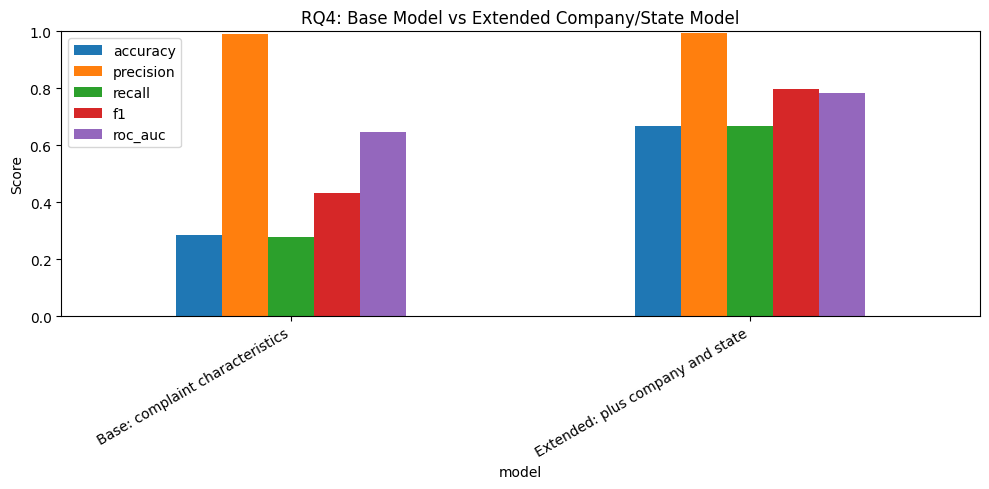

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/rq4_base_vs_extended_model_comparison.png


PosixPath('/content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/rq4_base_vs_extended_model_comparison.png')

In [26]:
# -------------------------------------------------------------------
# RQ4: Visual model comparison
# -------------------------------------------------------------------
plot_metric_comparison(
    rq4_model_comparison,
    title="RQ4: Base Model vs Extended Company/State Model",
    filename="rq4_base_vs_extended_model_comparison.png"
)

## RQ4 Preliminary Interpretation

Suggested wording for the report:

> Company and state were tested as grouped categorical variables. Chi-square tests show whether each variable is statistically associated with timely response. The logistic model comparison shows whether adding company and state improves predictive performance after controlling for product, issue, submission channel, and year. Any improvement should be interpreted carefully because complaint counts do not represent total customer base or market share.

# Final Hypothesis Summary

This section combines the key test results into one table for reporting.

In [27]:
# -------------------------------------------------------------------
# Final hypothesis summary table
# -------------------------------------------------------------------
summary_rows = []

summary_rows.append({
    "research_question": "RQ1",
    "test": "Chi-square: product vs timely response",
    "p_value": rq1_summary.loc[0, "p_value"],
    "effect_size": rq1_summary.loc[0, "cramers_v"],
    "decision": rq1_summary.loc[0, "p_value_interpretation"],
    "effect_interpretation": rq1_summary.loc[0, "effect_size_interpretation"]
})

summary_rows.append({
    "research_question": "RQ2",
    "test": "Chi-square: issue group vs company response",
    "p_value": rq2_summary.loc[0, "p_value"],
    "effect_size": rq2_summary.loc[0, "cramers_v"],
    "decision": rq2_summary.loc[0, "p_value_interpretation"],
    "effect_interpretation": rq2_summary.loc[0, "effect_size_interpretation"]
})

summary_rows.append({
    "research_question": "RQ3",
    "test": "Model comparison: structured vs structured + narrative",
    "p_value": np.nan,
    "effect_size": rq3_model_comparison_final.loc[2, "roc_auc"],
    "decision": "Compare ROC-AUC/F1 improvement instead of p-value.",
    "effect_interpretation": "Positive difference suggests narrative features add predictive value."
})

summary_rows.append({
    "research_question": "RQ4A",
    "test": "Chi-square: company group vs timely response",
    "p_value": rq4_company_summary.loc[0, "p_value"],
    "effect_size": rq4_company_summary.loc[0, "cramers_v"],
    "decision": rq4_company_summary.loc[0, "p_value_interpretation"],
    "effect_interpretation": rq4_company_summary.loc[0, "effect_size_interpretation"]
})

summary_rows.append({
    "research_question": "RQ4B",
    "test": "Chi-square: state group vs timely response",
    "p_value": rq4_state_summary.loc[0, "p_value"],
    "effect_size": rq4_state_summary.loc[0, "cramers_v"],
    "decision": rq4_state_summary.loc[0, "p_value_interpretation"],
    "effect_interpretation": rq4_state_summary.loc[0, "effect_size_interpretation"]
})

summary_rows.append({
    "research_question": "RQ4C",
    "test": "Model comparison: base vs company/state extended model",
    "p_value": np.nan,
    "effect_size": rq4_model_comparison_final.loc[2, "roc_auc"],
    "decision": "Compare ROC-AUC/F1 improvement instead of p-value.",
    "effect_interpretation": "Positive difference suggests company/state add predictive value."
})

final_hypothesis_summary = pd.DataFrame(summary_rows)

# Round numeric columns
final_hypothesis_summary["p_value"] = final_hypothesis_summary["p_value"].astype(float).round(6)
final_hypothesis_summary["effect_size"] = final_hypothesis_summary["effect_size"].astype(float).round(6)

save_table(final_hypothesis_summary, "final_hypothesis_tests_summary.csv")

final_hypothesis_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_hypothesis_tests_summary.csv


,research_question,test,p_value,effect_size,decision,effect_interpretation
0,RQ1,Chi-square: product vs timely response,0.0,0.092789,Reject H0: statistically significant association.,Very weak effect size.
1,RQ2,Chi-square: issue group vs company response,0.0,0.187419,Reject H0: statistically significant association.,Weak effect size.
2,RQ3,Model comparison: structured vs structured + n...,NaN,0.055700,Compare ROC-AUC/F1 improvement instead of p-va...,Positive difference suggests narrative feature...
3,RQ4A,Chi-square: company group vs timely response,0.0,0.124584,Reject H0: statistically significant association.,Weak effect size.
4,RQ4B,Chi-square: state group vs timely response,0.0,0.018671,Reject H0: statistically significant association.,Very weak effect size.
5,RQ4C,Model comparison: base vs company/state extend...,NaN,0.135600,Compare ROC-AUC/F1 improvement instead of p-va...,Positive difference suggests company/state add...


## Final Report Writing Notes

You can use the table above in the methodology and findings sections of the capstone report.

Recommended language:

- Use **statistically associated** instead of **causes**.
- Use **predictive value** instead of **proof** when discussing model comparisons.
- Mention that the CFPB data is observational and public complaint data.
- Mention that complaint counts do not represent total bank customer base or market share.
- Mention that large datasets can produce very small p-values, so effect size matters.

## Next Step

Continue with:

`04_model_training.ipynb`

That notebook should build the full machine learning pipeline, including:

- train/test split;
- structured-only model;
- structured + TF-IDF narrative model;
- logistic regression;
- random forest;
- class imbalance handling;
- ROC-AUC, F1, precision, recall;
- feature importance;
- model saving.